
   ÉTAPE 1 — CHARGEMENT TABLES DE FAITS
   Source : data/raw/ — lecture seule

Table        |   Lignes | Colonnes
--------------------------------------
  orders       |    99441 |        8
  items        |   112650 |        7
  payments     |   103886 |        5
  reviews      |    99224 |        7
  products     |    32951 |        9
  transl       |       71 |        2

✓ Tables de faits chargées — aucune modification encore

   ÉTAPE 2 — NETTOYAGE : orders
   Cours 1 P2F — standardisation dates
   Cours 3 §2 — order_status = variable nominale

✓ 5 colonne(s) converties en datetime
✓ Lignes supprimées (delivered sans date) : 8
✓ orders restantes                        : 99433
✓ order_status → category (8 valeurs uniques)

✓ Vérification nulls orders :
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1782
order_

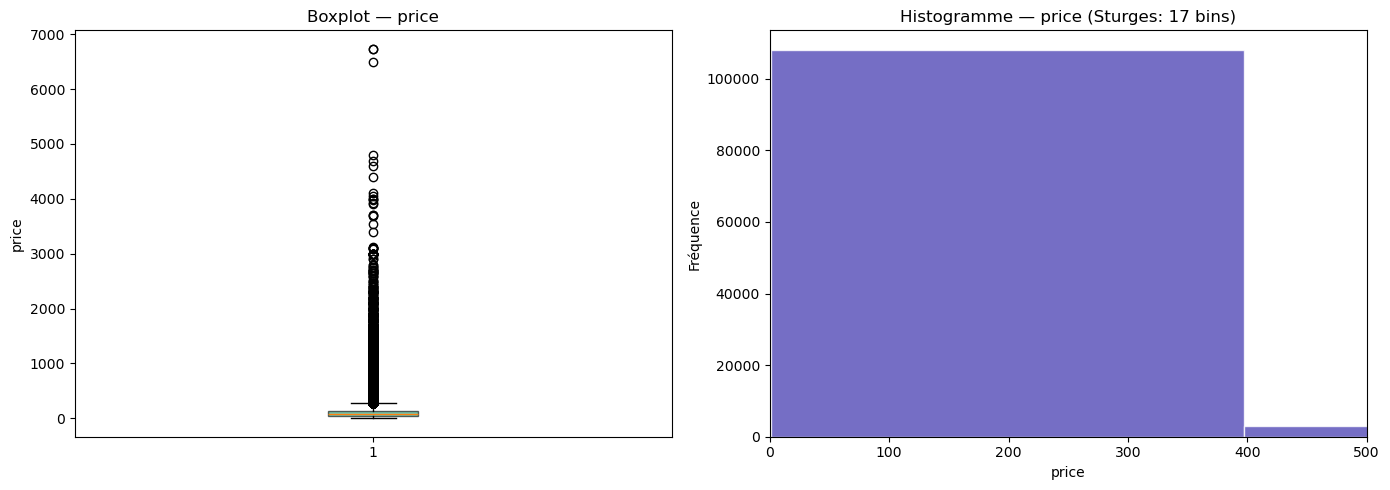

--- Visualisation : freight_value ---
✓ Figure sauvegardée : ../reports/figures/02_freight_distribution.png


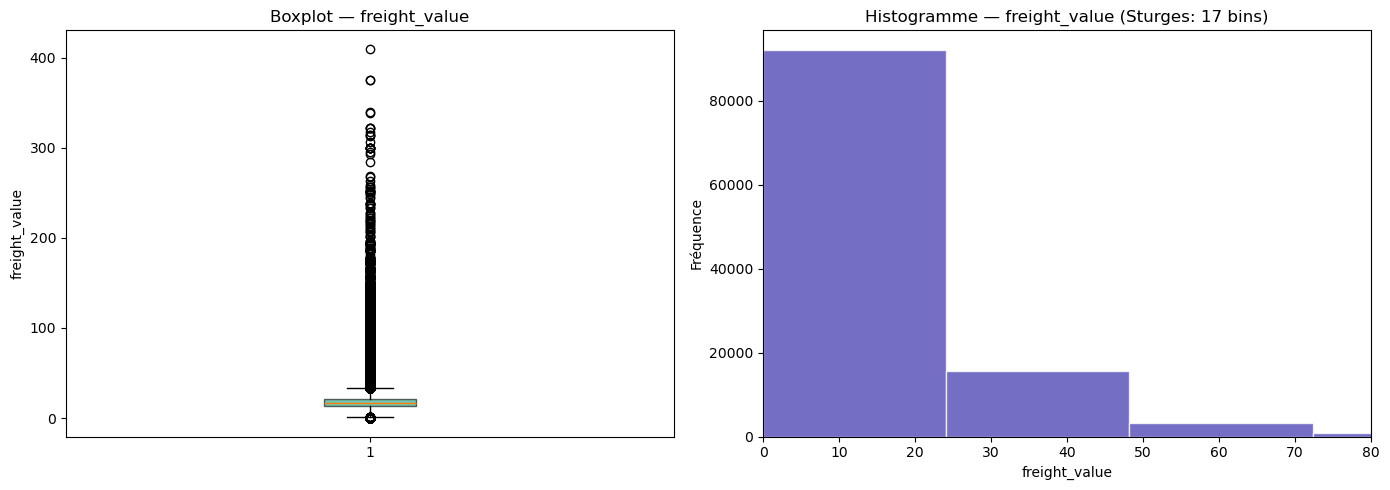

--- Visualisation : scatter prix vs fret ---
✓ Figure sauvegardée : ../reports/figures/03_scatter_price_freight.png


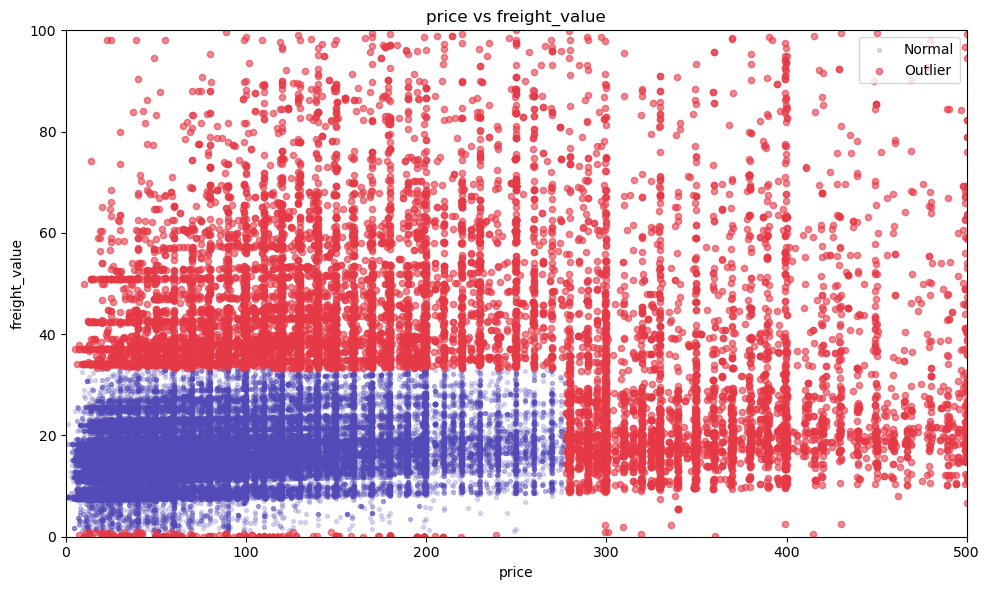


   ÉTAPE 9 — RAPPORT FINAL TABLES DE FAITS

Table        |   Lignes |    Nulls | Categ. | Dates
-------------------------------------------------------
  orders       |    99433 |     4899 |      1 |     5
  items        |   112650 |        0 |      0 |     1
  payments     |   103886 |        0 |      1 |     0
  reviews      |    99224 |   145903 |      0 |     2
  products     |    32951 |        0 |      0 |     0

   ÉTAPE 10 — EXPORT : data/processed/

✓ orders       → ../data/processed/orders_clean.csv
✓ items        → ../data/processed/items_clean.csv
✓ payments     → ../data/processed/payments_clean.csv
✓ reviews      → ../data/processed/reviews_clean.csv
✓ products     → ../data/processed/products_clean.csv

✓ 5 tables exportées dans data/processed/
✓ Figures sauvegardées dans reports/figures/

   ✓ 02_data_cleaning.ipynb TERMINÉ
   → Exécuter ensuite : 03_data_support.ipynb


In [ ]:
# ============================================================
# 02_data_cleaning.ipynb — NETTOYAGE TABLES DE FAITS
# Tables traitées : orders, items, payments, reviews, products
# Source : data/raw/ → data/processed/
# Cours activé : Cours 1 complet + Cours 3 §2,3,4
# ============================================================

import sys
sys.path.append('..')
from src.utils import *

# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 1 — CHARGEMENT TABLES DE FAITS")
print("   Source : data/raw/ — lecture seule")
print("="*60 + "\n")
# -------------------------------------------------------

orders   = pd.read_csv('../data/raw/olist_orders_dataset.csv')
items    = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
reviews  = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
transl   = pd.read_csv('../data/raw/product_category_name_translation.csv')

print(f"{'Table':<12} | {'Lignes':>8} | {'Colonnes':>8}")
print("-" * 38)
for name, df in [('orders',orders),('items',items),('payments',payments),
                 ('reviews',reviews),('products',products),('transl',transl)]:
    print(f"  {name:<12} | {len(df):>8} | {df.shape[1]:>8}")

print("\n✓ Tables de faits chargées — aucune modification encore")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 2 — NETTOYAGE : orders")
print("="*60 + "\n")
# -------------------------------------------------------

# Conversion des 5 colonnes dates en datetime
# Cours 1 P2F : standardiser les formats de dates
orders = convertir_dates(orders, [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# Supprimer les 8 commandes 'delivered' sans date de livraison
# Audit étape 6 : erreurs réelles — incohérence statut/date
# Les autres nulls dates = nulls métier (commandes non livrées) → gardés
avant = len(orders)
orders = orders[~(
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isnull())
)]
print(f"✓ Lignes supprimées (delivered sans date) : {avant - len(orders)}")
print(f"✓ orders restantes                        : {len(orders)}")

# order_status → variable nominale → category
# Cours 3 §2 : pas de calcul numérique sur une variable nominale
orders = convertir_categories(orders, ['order_status'])

# Vérification finale
print(f"\n✓ Vérification nulls orders :")
print(orders.isnull().sum())
print(f"\n✓ Distribution order_status :")
print(orders['order_status'].value_counts())


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 3 — NETTOYAGE : order_items")
print("   boxplot + scatter")
print("   IQR sur données skewed")
print("   dispersion et outliers")
print("="*60 + "\n")
# -------------------------------------------------------

# Convertir shipping_limit_date en datetime
items = convertir_dates(items, ['shipping_limit_date'])

# Vérification cohérence — prix et fret ne peuvent pas être négatifs
print("--- Vérification cohérence ---")
print(f"Prix négatifs     : {(items['price'] < 0).sum()}")
print(f"Fret négatifs     : {(items['freight_value'] < 0).sum()}")
print(f"Prix égaux à 0    : {(items['price'] == 0).sum()}")

# IQR sur price
# Méthode IQR choisie car prix = distribution skewed à droite
# Cours 3 §4 : médiane robuste sur données asymétriques
# Cours 1 P3B : IQR = Q3 - Q1, bornes à 1.5×IQR
items, b_low_p, b_high_p = detecter_outliers_iqr(items, 'price')

# IQR sur freight_value
items, b_low_f, b_high_f = detecter_outliers_iqr(items, 'freight_value')

# Anomalie bivariée : fret > prix du produit
# Cours 1 P2C : anomalie visible seulement dans la relation entre 2 variables
items['fret_sup_prix'] = items['freight_value'] > items['price']
print(f"✓ Cas fret > prix : {items['fret_sup_prix'].sum()} "
      f"({items['fret_sup_prix'].mean()*100:.1f}%)")

# Flag combiné pour visualisation
items['any_outlier'] = (
    items['price_is_outlier'] | items['freight_value_is_outlier']
)

print(f"\n✓ Vérification nulls items :")
print(items.isnull().sum())


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 4 — NETTOYAGE : order_payments")
print("   Cours 3 §2 — payment_type = variable nominale")
print("="*60 + "\n")
# -------------------------------------------------------

# payment_type → variable nominale → category
payments = convertir_categories(payments, ['payment_type'])

# 3 lignes 'not_defined' → flag sans suppression
# Règle pro : isoler avant de décider, ne pas supprimer aveuglément
payments['payment_is_unknown'] = payments['payment_type'] == 'not_defined'
print(f"✓ Paiements 'not_defined' flaggés : "
      f"{payments['payment_is_unknown'].sum()}")

print(f"\n✓ Distribution payment_type :")
print(payments['payment_type'].value_counts())

print(f"\n✓ Vérification nulls payments :")
print(payments.isnull().sum())


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 5 — NETTOYAGE : order_reviews")
print("   Cours 3 §2 — review_score = variable ordinale")
print("   Nulls commentaires = intentionnels → gardés")
print("="*60 + "\n")
# -------------------------------------------------------

# Convertir les dates en datetime
reviews = convertir_dates(reviews, [
    'review_creation_date',
    'review_answer_timestamp'
])

# review_score : 0 null confirmé par l'audit → aucun traitement
print(f"✓ review_score nulls : {reviews['review_score'].isnull().sum()}")
print(f"  Gardé en int64 — variable ordinale, médiane valide")
print(f"  Moyenne = approximation acceptable (compromis pragmatique)")

# Nulls commentaires → intentionnels, on ne touche pas
# Cours 3 §2 : ces colonnes texte sont optionnelles par design
print(f"\n✓ Nulls commentaires conservés (optionnels par design) :")
print(f"  review_comment_title   : "
      f"{reviews['review_comment_title'].isnull().sum()}")
print(f"  review_comment_message : "
      f"{reviews['review_comment_message'].isnull().sum()}")

print(f"\n✓ Distribution review_score :")
print(reviews['review_score'].value_counts().sort_index())


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 6 — NETTOYAGE : products")
print("="*60 + "\n")
# -------------------------------------------------------

# 610 produits sans catégorie → imputer 'unknown'
# Audit étape 7 : 1603 commandes attachées → suppression impossible
products['product_category_name'] = (
    products['product_category_name'].fillna('unknown')
)
print(f"✓ Catégories nulles → 'unknown'")
print(f"  Nulls restants : {products['product_category_name'].isnull().sum()}")

# Dimensions physiques (2 nulls) → médiane
# Cours 3 §3 : médiane robuste aux outliers
# Un produit très lourd ne tire pas la valeur d'imputation vers le haut
products = imputer_mediane(products, [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
])

# Colonnes texte (610 nulls) → médiane
products = imputer_mediane(products, [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty'
])

# product_category_name → variable nominale → category
products = convertir_categories(products, ['product_category_name'])

print(f"\n✓ Vérification nulls products :")
print(products.isnull().sum())


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 7 — MERGE : products + translation")
print("   Traduire catégories portugais → anglais")
print("   Nécessaire pour lisibilité Power BI")
print("="*60 + "\n")
# -------------------------------------------------------

avant_cols = products.shape[1]

products = products.merge(
    transl,
    on='product_category_name',
    how='left'
)

# 'unknown' et catégories sans traduction → imputer 'unknown'
products['product_category_name_english'] = (
    products['product_category_name_english'].fillna('unknown')
)

print(f"✓ Colonnes avant merge : {avant_cols}")
print(f"✓ Colonnes après merge : {products.shape[1]}")
print(f"✓ Catégories traduites : "
      f"{products['product_category_name_english'].nunique()}")
print(f"\n✓ Exemple traductions :")
print(products[['product_category_name',
                'product_category_name_english']]
      .drop_duplicates()
      .head(8)
      .to_string(index=False))


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 8 — VISUALISATIONS : distributions")
print("   Cours 1 P2A — Boxplot")
print("   Cours 1 P2B — Histogramme (règle de Sturges)")
print("   Cours 1 P2C — Scatter plot anomalies bivariées")
print("="*60 + "\n")
# -------------------------------------------------------

import os
os.makedirs('../reports/figures', exist_ok=True)

# Boxplot + histogramme des prix
print("--- Visualisation : price ---")
plot_boxplot_hist(
    items, 'price',
    save_path='../reports/figures/01_price_distribution.png',
    xlim=(0, 500)
)

# Boxplot + histogramme du fret
print("--- Visualisation : freight_value ---")
plot_boxplot_hist(
    items, 'freight_value',
    save_path='../reports/figures/02_freight_distribution.png',
    xlim=(0, 80)
)

# Scatter plot prix vs fret — anomalies bivariées
# Cours 1 P2C : anomalie bivariée = normale seule, anormale en relation
print("--- Visualisation : scatter prix vs fret ---")
plot_scatter_outliers(
    items, 'price', 'freight_value',
    flag_col='any_outlier',
    save_path='../reports/figures/03_scatter_price_freight.png',
    xlim=(0, 500),
    ylim=(0, 100)
)


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 9 — RAPPORT FINAL TABLES DE FAITS")
print("="*60 + "\n")
# -------------------------------------------------------

tables_faits = {
    'orders':   orders,
    'items':    items,
    'payments': payments,
    'reviews':  reviews,
    'products': products
}

print(f"{'Table':<12} | {'Lignes':>8} | {'Nulls':>8} | "
      f"{'Categ.':>6} | {'Dates':>5}")
print("-" * 55)

for name, df in tables_faits.items():
    nulls     = df.isnull().sum().sum()
    cat_cols  = len(df.select_dtypes('category').columns)
    date_cols = len(df.select_dtypes('datetime64').columns)
    print(f"  {name:<12} | {len(df):>8} | {nulls:>8} | "
          f"{cat_cols:>6} | {date_cols:>5}")


# -------------------------------------------------------
print("\n" + "="*60)
print("   ÉTAPE 10 — EXPORT : data/processed/")
print("="*60 + "\n")
# -------------------------------------------------------

os.makedirs('../data/processed', exist_ok=True)

for name, df in tables_faits.items():
    path = f'../data/processed/{name}_clean.csv'
    df.to_csv(path, index=False)
    print(f"✓ {name:<12} → {path}")

print(f"\n✓ {len(tables_faits)} tables exportées dans data/processed/")
print(f"✓ Figures sauvegardées dans reports/figures/")
print("\n" + "="*60)
print("   ✓ 02_data_cleaning.ipynb TERMINÉ")
print("   → Exécuter ensuite : 03_data_support.ipynb")
print("="*60)